# Test ridge regression approach

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import mesoscopy.io as io
import mesoscopy.process.regression as regr
import numpy as np

In [2]:
path = "../scratch/sub-MM229_exp-109hrb21d_ses-20220329_behaviour-hf_meso_preprocessed_registered_smoothed_zscored.h5"

session_id, deltaf, timestamps = io.load_deltaf(path)

In [3]:
deltaf

array([[[ 0.5395146 ,  0.39834934,  0.09742619, ..., -0.51102346,
         -0.6369774 , -0.6850537 ],
        [ 0.57616556,  0.46668014,  0.20956166, ..., -0.8565719 ,
         -0.9435722 , -0.95682585],
        [ 0.6336549 ,  0.5499257 ,  0.33119327, ..., -1.0572137 ,
         -1.1151086 , -1.1075232 ],
        ...,
        [-1.1533234 , -1.0994579 , -1.055682  , ..., -0.35241786,
         -0.3190647 , -0.26349524],
        [-1.0240782 , -0.98761815, -0.9357003 , ..., -0.38678637,
         -0.2992319 , -0.20419511],
        [-0.84570014, -0.828648  , -0.7707028 , ..., -0.39527693,
         -0.28070655, -0.16718096]],

       [[ 0.43171102,  0.30653659,  0.04746052, ...,  2.0289865 ,
          2.0324636 ,  1.9346529 ],
        [ 0.12286529,  0.05752036, -0.11092722, ...,  1.8010553 ,
          1.8731807 ,  1.8225921 ],
        [-0.2871061 , -0.28766358, -0.35498008, ...,  1.6122864 ,
          1.7403109 ,  1.7313881 ],
        ...,
        [-1.252647  , -1.2719169 , -1.3320942 , ..., -

In [4]:
regressor_file = np.load("../scratch/sub-MM229_exp-109hrb21d_ses-20220329_behaviour-gonogo_regressors.npz")
regressors = regressor_file["regressors"]

In [5]:
regressors

array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]], shape=(37341, 6))

In [57]:
deltaf

array([[[ 0.5395146 ,  0.39834934,  0.09742619, ..., -0.51102346,
         -0.6369774 , -0.6850537 ],
        [ 0.57616556,  0.46668014,  0.20956166, ..., -0.8565719 ,
         -0.9435722 , -0.95682585],
        [ 0.6336549 ,  0.5499257 ,  0.33119327, ..., -1.0572137 ,
         -1.1151086 , -1.1075232 ],
        ...,
        [-1.1533234 , -1.0994579 , -1.055682  , ..., -0.35241786,
         -0.3190647 , -0.26349524],
        [-1.0240782 , -0.98761815, -0.9357003 , ..., -0.38678637,
         -0.2992319 , -0.20419511],
        [-0.84570014, -0.828648  , -0.7707028 , ..., -0.39527693,
         -0.28070655, -0.16718096]],

       [[ 0.43171102,  0.30653659,  0.04746052, ...,  2.0289865 ,
          2.0324636 ,  1.9346529 ],
        [ 0.12286529,  0.05752036, -0.11092722, ...,  1.8010553 ,
          1.8731807 ,  1.8225921 ],
        [-0.2871061 , -0.28766358, -0.35498008, ...,  1.6122864 ,
          1.7403109 ,  1.7313881 ],
        ...,
        [-1.252647  , -1.2719169 , -1.3320942 , ..., -

In [58]:
y = deltaf[:, 100, 100]
trials_idx = regressor_file.get("trial_idx")
coefs = regr._pixel_ridge_regression(y[trials_idx], regressors)

In [59]:
regressor_file.keys()

KeysView(NpzFile '../scratch/sub-MM229_exp-109hrb21d_ses-20220329_behaviour-gonogo_regressors.npz' with keys: regressors, labels, timestamps, trial_idx)

In [60]:
trials_idx = regressor_file.get("trial_idx")
coefs, r2, mse = regr.ridge_regression(deltaf[trials_idx], regressors)

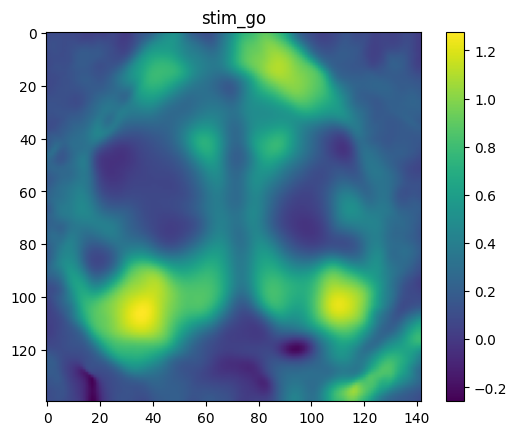

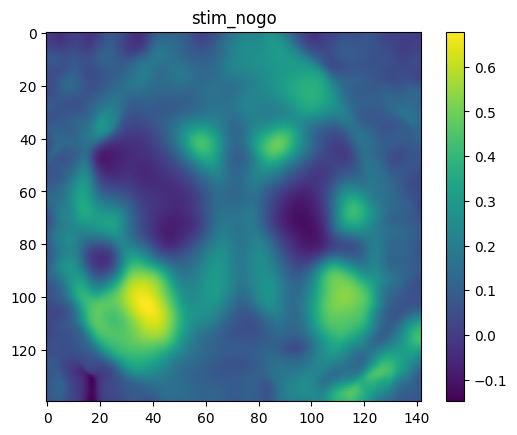

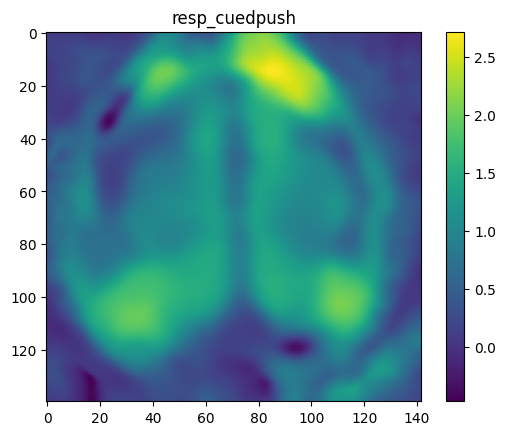

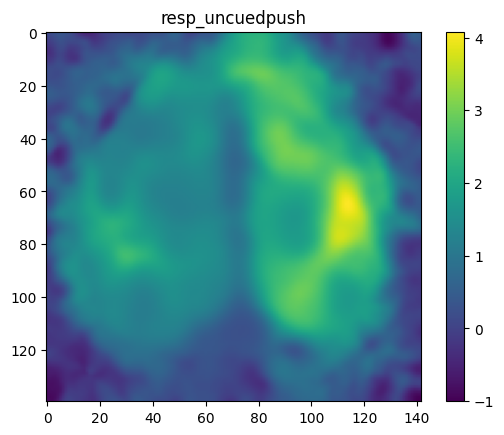

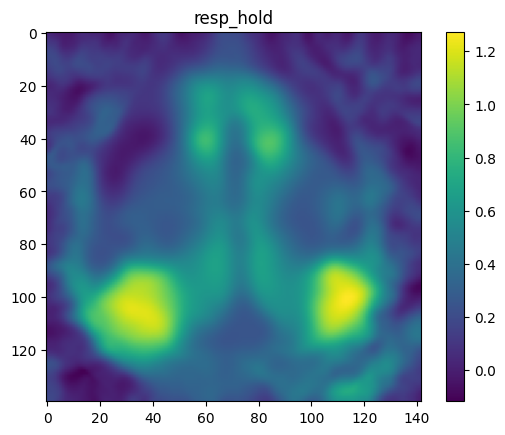

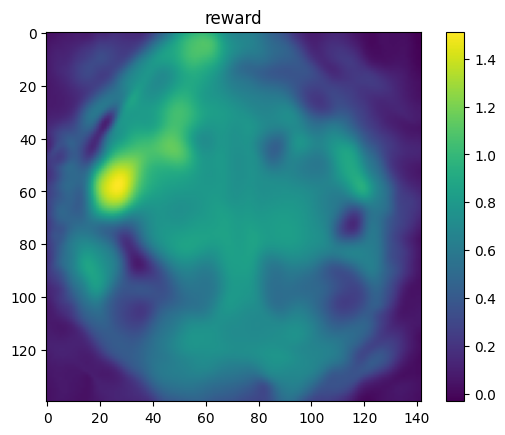

In [61]:
# plot coefficients for each regressor with their labels
for i, label in enumerate(regressor_file.get("labels")):
    plt.figure()
    plt.imshow(coefs[i])
    plt.title(label)
    plt.colorbar()
    plt.show()

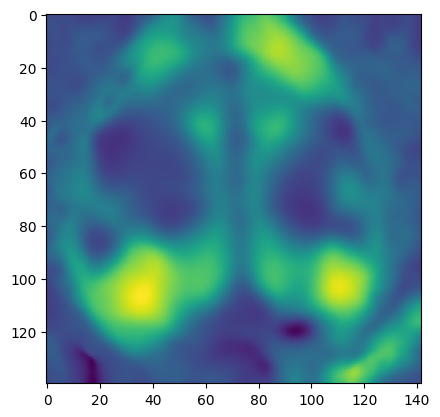

In [62]:
plt.imshow(coefs[0])

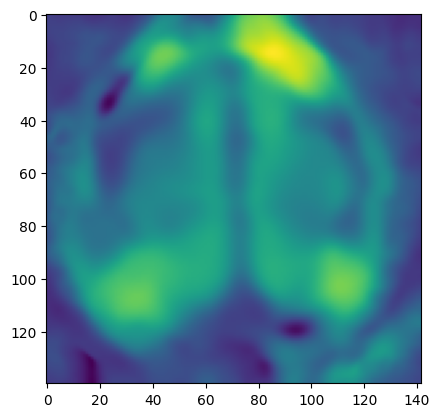

In [63]:
plt.imshow(coefs[2])

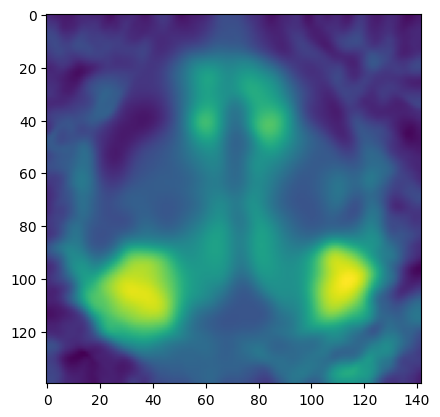

In [64]:
plt.imshow(coefs[4])

# fast

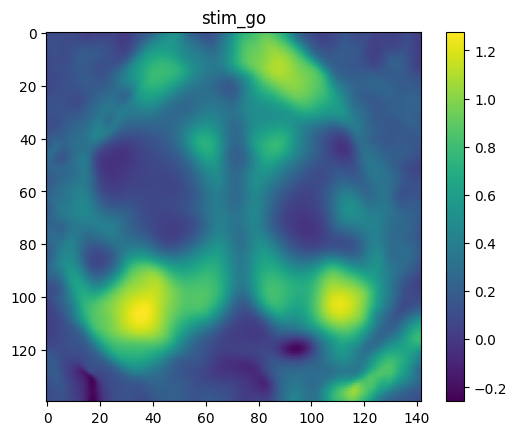

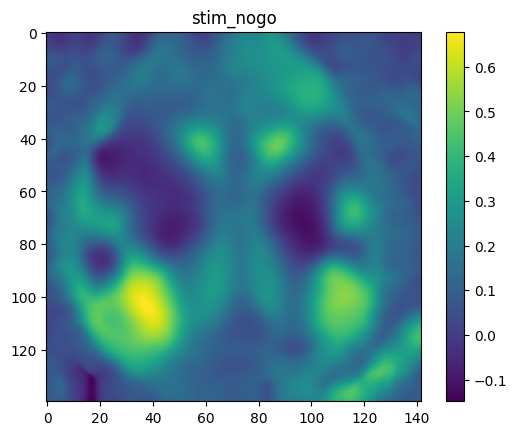

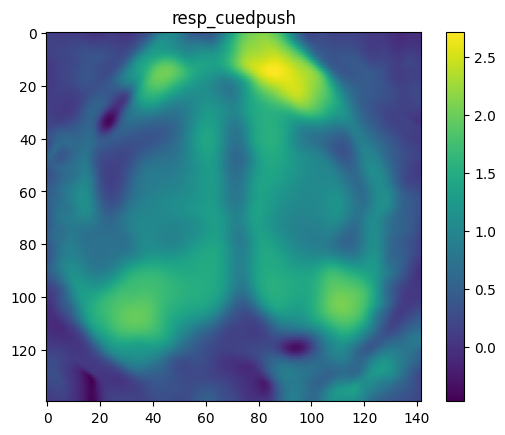

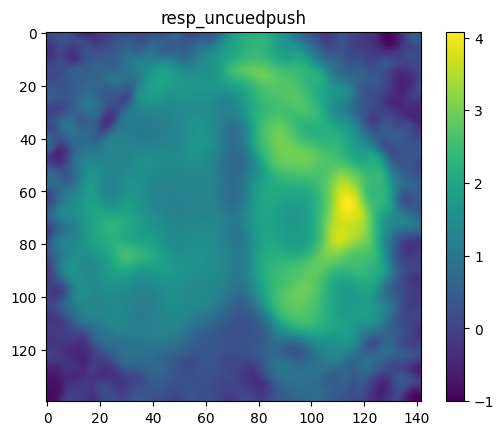

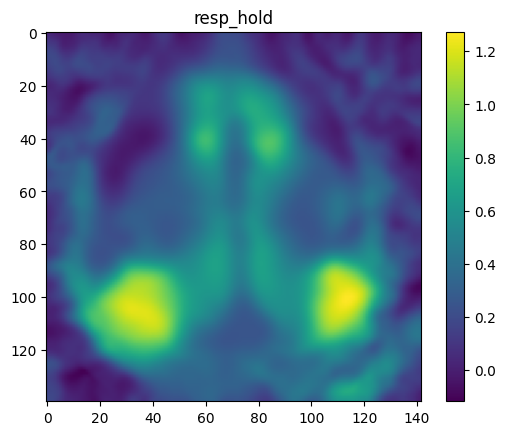

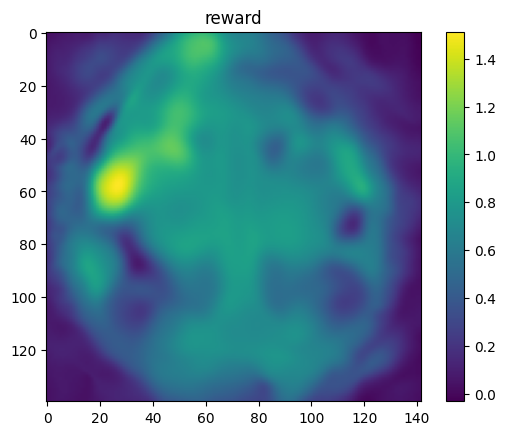

In [6]:
trials_idx = regressor_file.get("trial_idx")
coefs, r2, mse = regr.ridge_regression_fast(deltaf[trials_idx], regressors)

# plot coefficients for each regressor with their labels
for i, label in enumerate(regressor_file.get("labels")):
    plt.figure()
    plt.imshow(coefs[i])
    plt.title(label)
    plt.colorbar()
    plt.show()